In [221]:

from pathlib import Path

import pandas as pd
from sqlalchemy import create_engine

from nhs_waiting_lists import (
    __app_name__,
)
from nhs_waiting_lists.constants import OTHER_ACUTE_PROVIDER_CODES
from nhs_waiting_lists.constants import TOTAL_ONLY_TREATMENT_CODES
from nhs_waiting_lists.constants import proj_db_path, DB_FILE
from nhs_waiting_lists.utils.canned_queries import get_consolidated_df
from nhs_waiting_lists.utils.normality import test_normality
from nhs_waiting_lists.utils.xdg import XDGBasedir

project_root = Path(XDGBasedir.get_data_dir(__app_name__))

DB_PATH = project_root / proj_db_path / DB_FILE
FILES_DIR = project_root / "files"

engine = create_engine(f"sqlite:///{DB_PATH}")

# Get the 23 large acute trust provider codes, identified by the ranking table csv
PROVIDER_CODES = OTHER_ACUTE_PROVIDER_CODES

# Get the C_999 meta-treatment code which aggregates all other treatment codes
TREATMENT_CODES = TOTAL_ONLY_TREATMENT_CODES
# TREATMENT_CODES = ALL_TREATMENT_CODES

In [222]:


#| echo: false
#| output: false

## Retrieve all the provider rtt summary data

start_period = "2024-01"
end_period = "2024-12"

print(f"{PROVIDER_CODES=}")
print(f"{TREATMENT_CODES=}")

consolidated_df = get_consolidated_df(
    start_period,
    end_period,
    PROVIDER_CODES,
    TREATMENT_CODES,
)

consolidated_df["delta"] = consolidated_df["new_periods"]- consolidated_df["completed"]

aggregation_functions = {
    'incomplete': 'sum',
    'incomplete_prev': 'sum',
    'new_periods': 'sum',
    'treated': 'sum',
    'untreated': 'sum',
    'total_treatable': 'sum'
}

grouped_df: pd.DataFrame = consolidated_df.groupby(['period'])[[
    'incomplete_prev',
    'new_periods',
    'completed',
    "total_treatable",
    'untreated',
    "incomplete_expected",
    "incomplete",
    "delta"
]].sum().reset_index()



df = consolidated_df

df["unexplained_pct"] = df["untreated"] / df["total_treatable"]

df


PROVIDER_CODES=['R0B', 'RDE', 'RDU', 'REF', 'RGN', 'RH8', 'RHU', 'RHW', 'RJ2', 'RL4', 'RN5', 'RTE', 'RTF', 'RVJ', 'RWD', 'RWF', 'RWH', 'RWP', 'RWY', 'RXC', 'RXK', 'RXR']
TREATMENT_CODES=('C_999',)


,period,provider,treatment,untreated,new_periods,incomplete,incomplete_prev,incomplete_diff,completed,treated,provider_name,provider_type,provider_subtype,total_treatable,incomplete_expected,delta,unexplained_pct
0,2024-01-01,R0B,C_999,-2871,18812,60893,60550,343,15598,15598,South Tyneside and Sunderland NHS Foundation T...,Acute trust,Acute - Large,79362,63764,3214,-0.036176
1,2024-02-01,R0B,C_999,-2593,18924,62414,60893,1521,14810,14810,South Tyneside and Sunderland NHS Foundation T...,Acute trust,Acute - Large,79817,65007,4114,-0.032487
2,2024-03-01,R0B,C_999,-3423,17715,62324,62414,-90,14382,14382,South Tyneside and Sunderland NHS Foundation T...,Acute trust,Acute - Large,80129,65747,3333,-0.042719
3,2024-04-01,R0B,C_999,-5070,18755,60982,62324,-1342,15027,15027,South Tyneside and Sunderland NHS Foundation T...,Acute trust,Acute - Large,81079,66052,3728,-0.062532
4,2024-05-01,R0B,C_999,-3010,19161,61709,60982,727,15424,15424,South Tyneside and Sunderland NHS Foundation T...,Acute trust,Acute - Large,80143,64719,3737,-0.037558
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
259,2024-08-01,RXR,C_999,-5467,13052,69363,72342,-2979,10564,10564,East Lancashire Hospitals NHS Trust,Acute trust,Acute - Large,85394,74830,2488,-0.064021
260,2024-09-01,RXR,C_999,-3592,13788,68142,69363,-1221,11417,11417,East Lancashire Hospitals NHS Trust,Acute trust,Acute - Large,83151,71734,2371,-0.043199
261,2024-10-01,RXR,C_999,-5202,15475,66279,68142,-1863,12136,12136,East Lancashire Hospitals NHS Trust,Acute trust,Acute - Large,83617,71481,3339,-0.062212
262,2024-11-01,RXR,C_999,-3425,14071,65265,66279,-1014,11660,11660,East Lancashire Hospitals NHS Trust,Acute trust,Acute - Large,80350,68690,2411,-0.042626


In [223]:
print(df[["unexplained_pct"]].describe())

       unexplained_pct
count       264.000000
mean         -0.030635
std           0.030158
min          -0.160402
25%          -0.040421
50%          -0.023700
75%          -0.011859
max           0.025248


<Axes: ylabel='Density'>

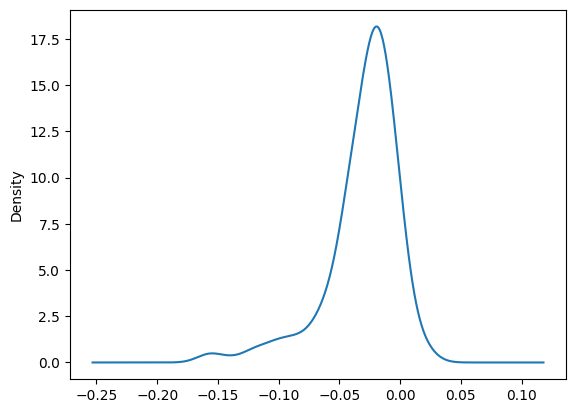

In [224]:
df["unexplained_pct"].plot.density()

In [225]:

pct_results = test_normality(df["unexplained_pct"].dropna(), "Delta")
normality_df = pd.DataFrame([pct_results])
print(normality_df.round(4))
pct_results

  return_type  n_obs    mean     std  skewness  kurtosis  shapiro_stat  \
0       Delta    264 -0.0306  0.0302   -1.7384    3.9665        0.8571   

   shapiro_p   jb_stat  jb_p  is_normal_shapiro  is_normal_jb  
0        0.0  306.0293   0.0              False         False  


{'return_type': 'Delta',
 'n_obs': 264,
 'mean': np.float64(-0.030635097680280648),
 'std': np.float64(0.030158480120801134),
 'skewness': np.float64(-1.7383933091450274),
 'kurtosis': np.float64(3.9664591898580577),
 'shapiro_stat': np.float64(0.8570953877481537),
 'shapiro_p': np.float64(6.5339123914658874e-15),
 'jb_stat': np.float64(306.0292806332326),
 'jb_p': np.float64(3.5203517513731364e-67),
 'is_normal_shapiro': np.False_,
 'is_normal_jb': np.False_}

In [226]:
from plotnine import (
    scale_x_datetime
)

df2 = consolidated_df.query('provider == "R0B" and treatment == "C_999"')[
    [
        "period",
        "incomplete",
        "incomplete_prev",
        "incomplete_diff",
        "untreated",
        "completed",
        "new_periods",
        "delta",
    ]
]

df2

,period,incomplete,incomplete_prev,incomplete_diff,untreated,completed,new_periods,delta
0,2024-01-01,60893,60550,343,-2871,15598,18812,3214
1,2024-02-01,62414,60893,1521,-2593,14810,18924,4114
2,2024-03-01,62324,62414,-90,-3423,14382,17715,3333
3,2024-04-01,60982,62324,-1342,-5070,15027,18755,3728
4,2024-05-01,61709,60982,727,-3010,15424,19161,3737
5,2024-06-01,61767,61709,58,-3065,14577,17700,3123
6,2024-07-01,61535,61767,-232,-2895,16902,19565,2663
7,2024-08-01,61293,61535,-242,-2816,14233,16807,2574
8,2024-09-01,61109,61293,-184,-2835,15753,18404,2651
9,2024-10-01,60837,61109,-272,-2805,17985,20518,2533


In [227]:
import statsmodels.api as sm

df3 = df2.dropna()

X = sm.add_constant(df3['delta'])
y = df3['untreated']
ols = sm.OLS(y, X).fit(cov_type='HC3')
print(ols.params, ols.rsquared)
print(ols.summary2())

const   -1474.323592
delta      -0.520938
dtype: float64 0.3631521098080046
                  Results: Ordinary least squares
Model:              OLS              Adj. R-squared:     0.299     
Dependent Variable: untreated        AIC:                190.9201  
Date:               2025-12-10 23:31 BIC:                191.8899  
No. Observations:   12               Log-Likelihood:     -93.460   
Df Model:           1                F-statistic:        3.194     
Df Residuals:       10               Prob (F-statistic): 0.104     
R-squared:          0.363            Scale:              4.0886e+05
--------------------------------------------------------------------
          Coef.     Std.Err.     z     P>|z|     [0.025      0.975] 
--------------------------------------------------------------------
const   -1474.3236  638.4124  -2.3094  0.0209  -2725.5889  -223.0582
delta      -0.5209    0.2915  -1.7871  0.0739     -1.0923     0.0504
-----------------------------------------------------

In [228]:

child_long = df2.reset_index().melt(
    id_vars=['period'],
    value_vars=['untreated', 'delta', 'incomplete_diff', 'new_periods', 'completed'],
    var_name='metric',
    value_name='value'
)


# child_long = child_long.groupby('metric').apply(
#     lambda x: x[(x['value'] >= x['value'].quantile(0.05)) &
#                 (x['value'] <= x['value'].quantile(0.95))],
#     include_groups=True
# ).reset_index(drop=True)

def remove_outliers(group: pd.DataFrame) -> pd.DataFrame:
    Q1 = group['value'].quantile(0.25)
    Q3 = group['value'].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    return group[(group['value'] >= lower) & (group['value'] <= upper)]


child_long = child_long.groupby('metric').apply(remove_outliers).reset_index(drop=True)

child_long

/tmp/ipykernel_3159826/489122434.py:24: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.


,period,metric,value
0,2024-01-01,completed,15598
1,2024-02-01,completed,14810
2,2024-03-01,completed,14382
3,2024-04-01,completed,15027
4,2024-05-01,completed,15424
5,2024-06-01,completed,14577
6,2024-07-01,completed,16902
7,2024-08-01,completed,14233
8,2024-09-01,completed,15753
9,2024-10-01,completed,17985


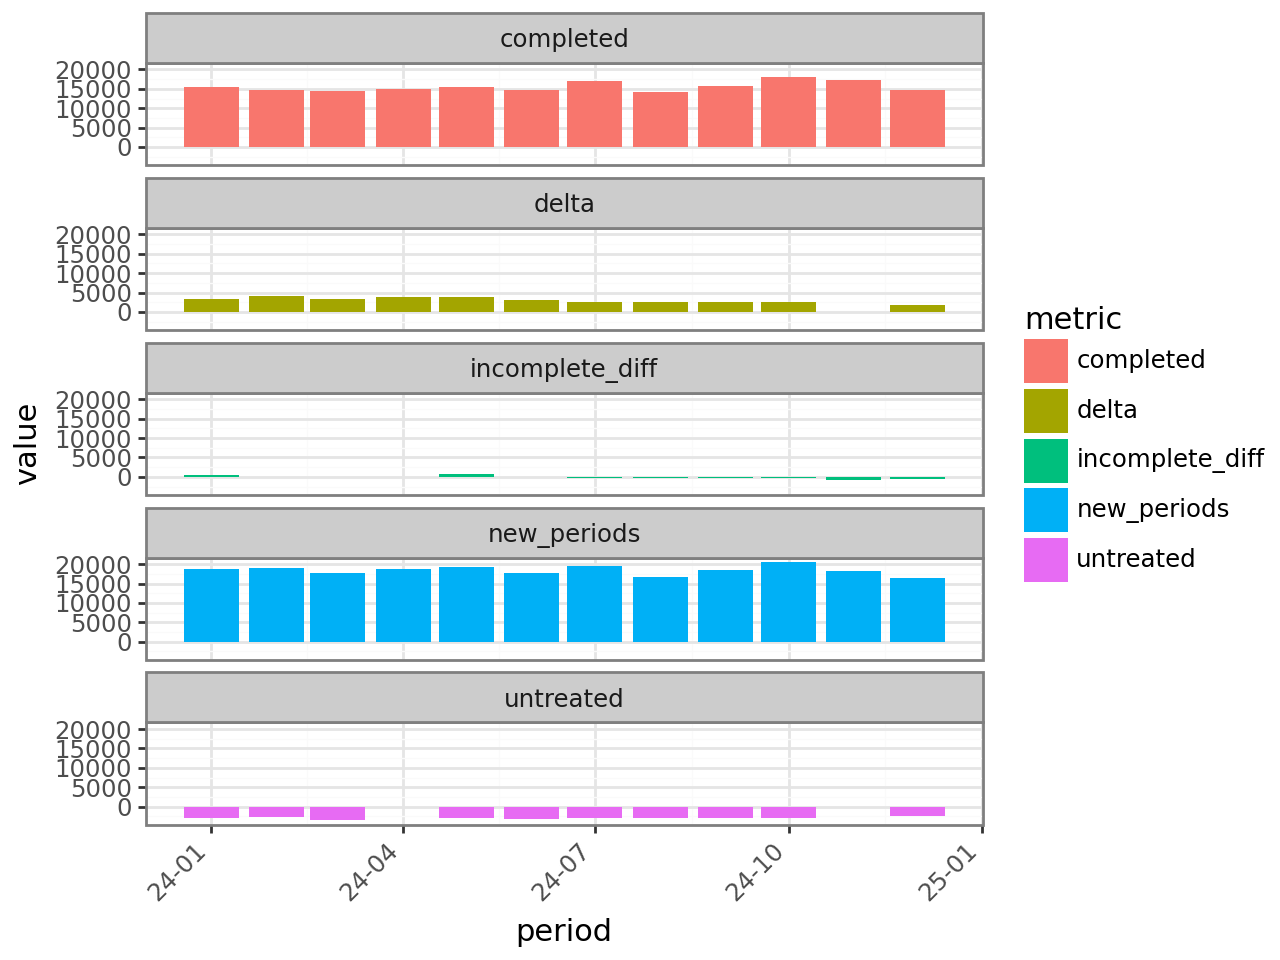

In [229]:
from plotnine import ggplot, aes, geom_col, facet_wrap, theme_bw, theme, element_text

p = (
        ggplot(child_long, aes(x="period", y="value", fill="metric"))
        + scale_x_datetime(date_labels="%y-%m")
        + geom_col(position="dodge")  # side-by-side bars
        + facet_wrap("~metric", ncol=1)
        + theme_bw()
        + theme(axis_text_x=element_text(rotation=45, hjust=1))
)
p



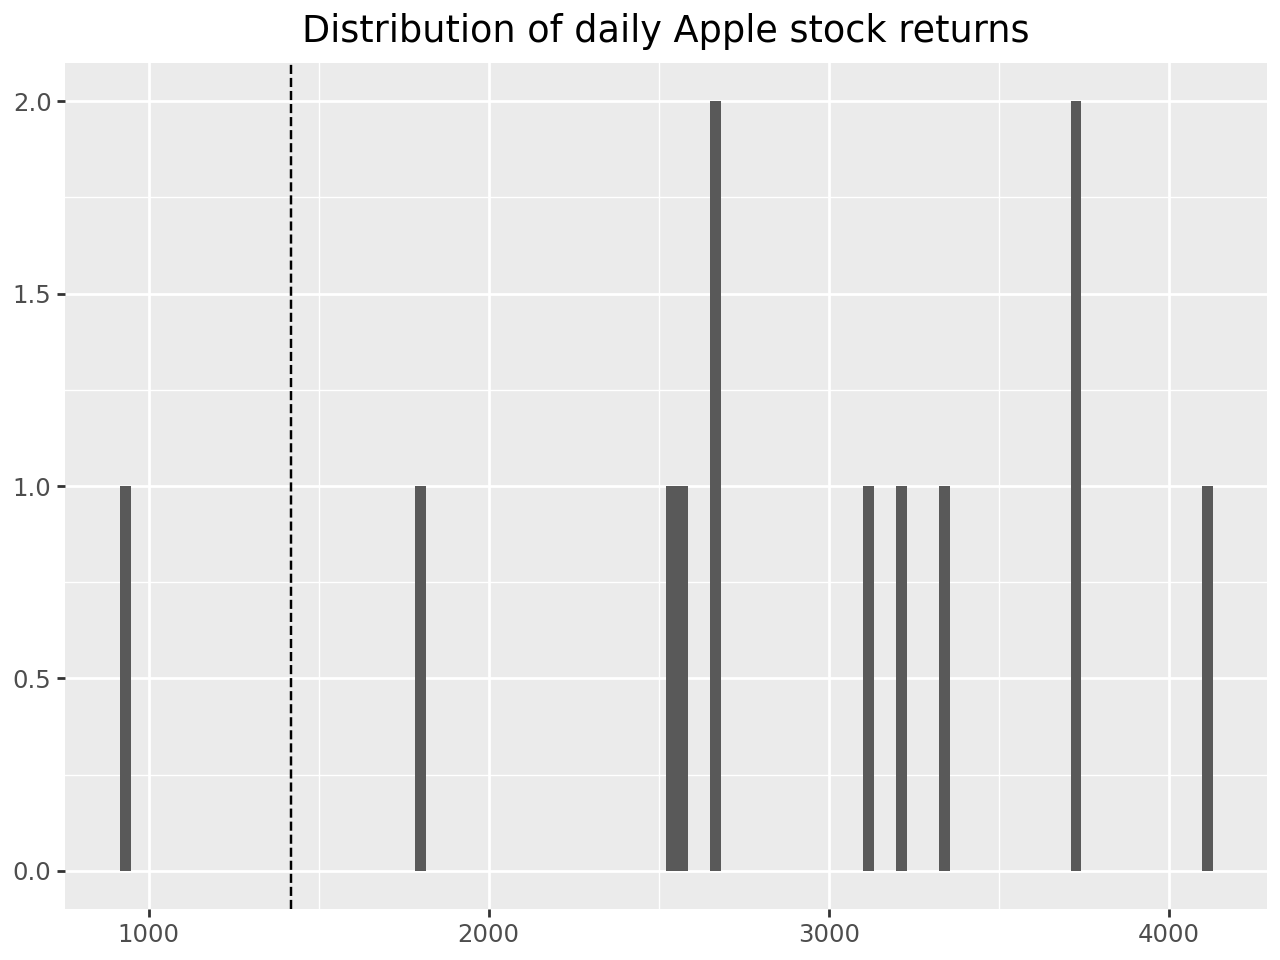

In [230]:
from mizani.formatters import percent_format
from plotnine import (
    ggplot, aes, geom_histogram, geom_vline, geom_qq,
    labs, scale_x_continuous, facet_wrap, theme_minimal,
    stat_qq_line, geom_density
)

quantile_05 = df2["delta"].quantile(0.05)

apple_returns_figure = (
        ggplot(df2, aes(x="delta"))
        + geom_histogram(bins=100)
        + geom_vline(aes(xintercept=quantile_05), linetype="dashed")
        + labs(x="", y="", title="Distribution of daily Apple stock returns")

)
apple_returns_figure.show()

In [231]:
child_long.groupby("metric")["value"].quantile(0.05).reset_index()

,metric,value
0,completed,14314.95
1,delta,2173.50
2,incomplete_diff,-765.15
3,new_periods,16684.60
4,untreated,-3261.90


In [232]:

quantiles = child_long.groupby("metric")["value"].quantile(0.05).reset_index()
quantiles.columns = ["return_type", "q05"]
quantiles

,return_type,q05
0,completed,14314.95
1,delta,2173.50
2,incomplete_diff,-765.15
3,new_periods,16684.60
4,untreated,-3261.90


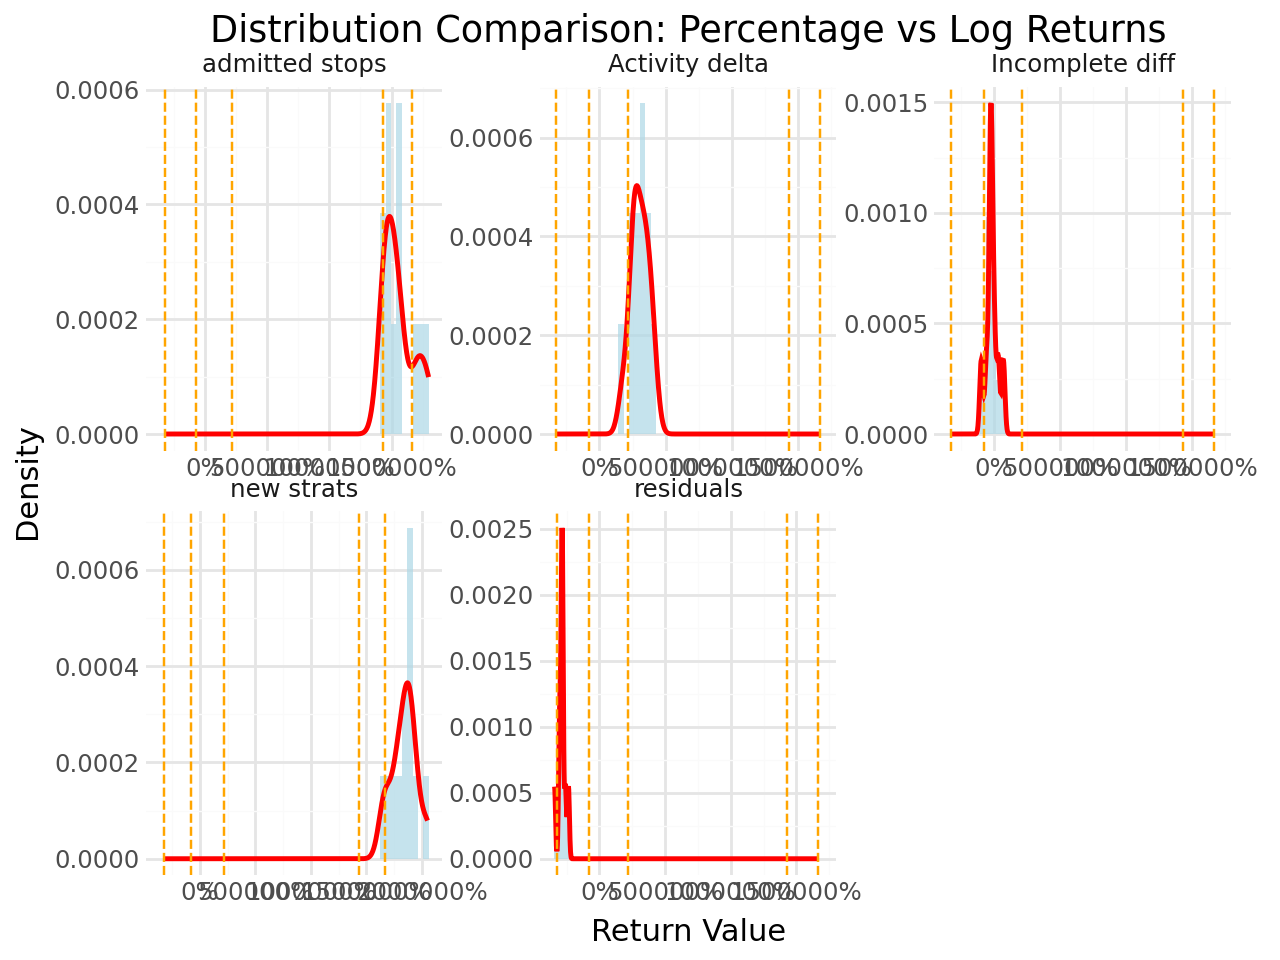

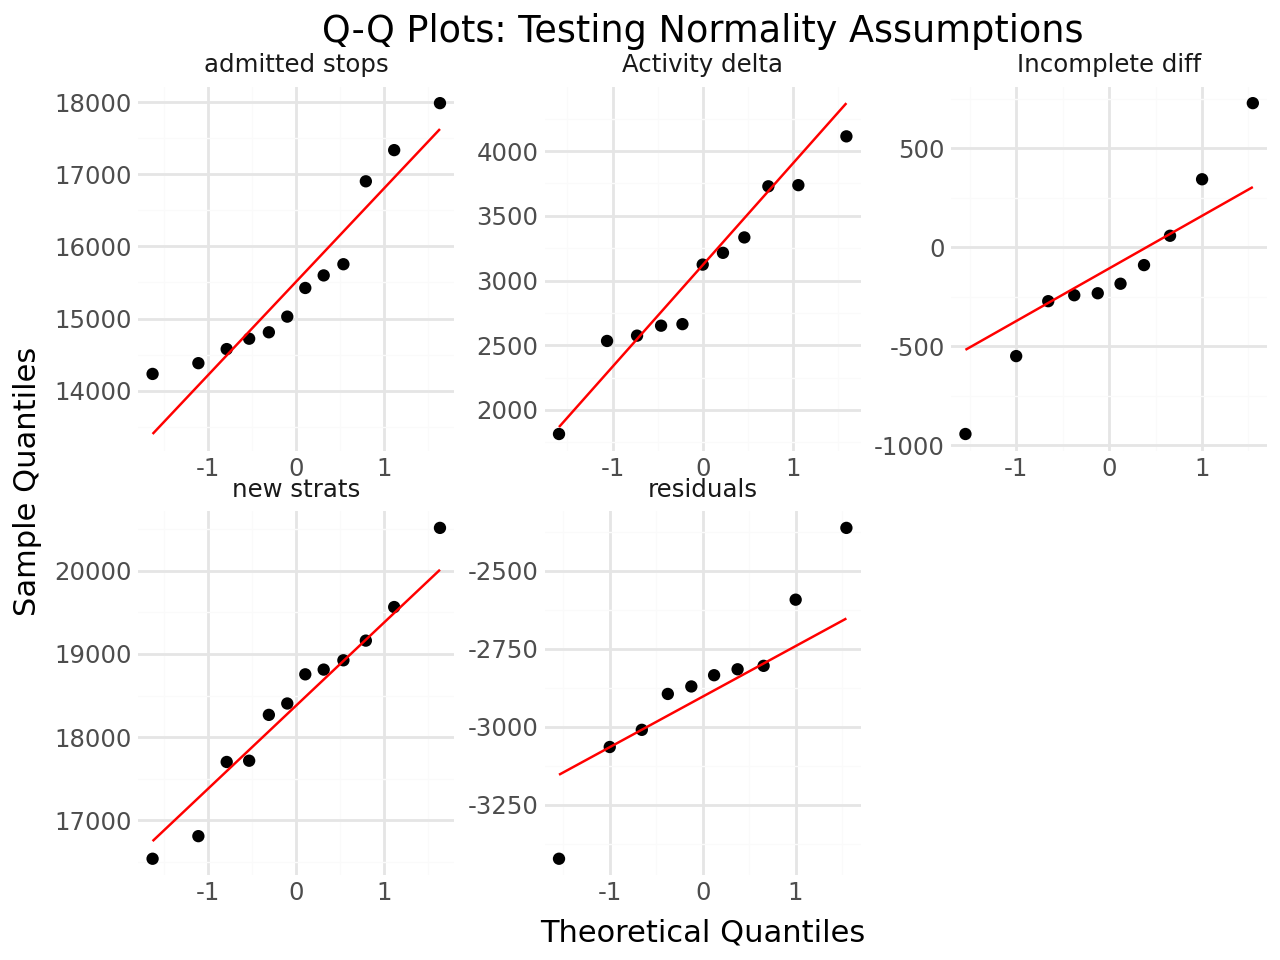


Normality Test Results:
          return_type  n_obs        mean        std  skewness  kurtosis  \
0               Delta     12   2868.0833   883.7502   -0.7036    0.0683   
1            Residual     12  -2968.4167   763.9609   -1.6575    3.1533   
2  Completed Pathways     12  15562.1667  1226.6440    0.8268   -0.6151   
3         New Periods     12  18430.2500  1127.1218   -0.0453   -0.4545   

   shapiro_stat  shapiro_p  jb_stat    jb_p  is_normal_shapiro  is_normal_jb  
0        0.9440     0.5513   0.9925  0.6088               True          True  
1        0.7908     0.0074  10.4662  0.0053              False         False  
2        0.8862     0.1053   1.5565  0.4592               True          True  
3        0.9762     0.9636   0.1074  0.9477               True          True  


In [234]:


returns_comparison = (
        ggplot(child_long, aes(x="value"))
        + geom_histogram(aes(y="..density.."), bins=50, alpha=0.7, fill="lightblue")
        + geom_density(color="red", size=1)
        + geom_vline(
    data=quantiles,
    mapping=aes(xintercept="q05"),
    linetype="dashed",
    color="orange"
)
        + facet_wrap("metric", scales="free", labeller=lambda x: {
    "delta": "Activity delta",
    "completed": "admitted stops",
    "incomplete_diff": "Incomplete diff",
    "new_periods": "new strats",
    "untreated": "residuals",
}[x])
        + labs(
    x="Return Value",
    y="Density",
    title="Distribution Comparison: Percentage vs Log Returns"
)
        + scale_x_continuous(labels=percent_format())
        + theme_minimal()
)

# For Q-Q plots to test normality more directly
qq_plot = (
        ggplot(child_long, aes(sample="value"))
        + geom_qq()
        + stat_qq_line(color="red")
        + facet_wrap("metric", scales="free", labeller=lambda x: {
    "delta": "Activity delta",
    "completed": "admitted stops",
    "incomplete_diff": "Incomplete diff",
    "new_periods": "new strats",
    "untreated": "residuals",
}[x])
        + labs(
    x="Theoretical Quantiles",
    y="Sample Quantiles",
    title="Q-Q Plots: Testing Normality Assumptions"
)
        + theme_minimal()
)

returns_comparison.show()
qq_plot.show()

pct_results = test_normality(df2["delta"].dropna(), "Delta")
log_results = test_normality(df2["untreated"].dropna(), "Residual")
nap_results = test_normality(df2["completed"].dropna(), "Completed Pathways")
np_results = test_normality(df2["new_periods"].dropna(), "New Periods")

normality_df = pd.DataFrame([pct_results, log_results, nap_results, np_results])
print("\nNormality Test Results:")
print(normality_df.round(4))

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import statsmodels.api as sm
import pandas as pd

provider = "R0B"
treatment = "C_301"

df3 = df2.dropna(subset=['delta', 'residual']).copy()

# Fit OLS
X = sm.add_constant(df3['delta'])
y = df3['residual']
ols = sm.OLS(y, X).fit(cov_type='HC3')

# Predictions
xvals = np.linspace(df3['delta'].min(), df3['delta'].max(), 200)
yhat = ols.params['const'] + ols.params['delta'] * xvals

# Parse period and flag COVID
df3['period'] = pd.to_datetime(df3['period'])
covid = (df3['period'].dt.year == 2020)

# --- Plot starts here ---
plt.figure(figsize=(8, 6))

# Scatter: two colours in same figure
plt.scatter(df3.loc[~covid, 'delta'], df3.loc[~covid, 'residual'],
            alpha=0.6, color='steelblue', label='Normal months')
plt.scatter(df3.loc[covid, 'delta'], df3.loc[covid, 'residual'],
            alpha=0.8, color='firebrick', label='COVID months')

# Regression line
plt.plot(xvals, yhat, color='darkorange', lw=2,
         label=f"OLS fit: y = {ols.params['delta']:.2f}x + {ols.params['const']:.1f}")

# Formatting
plt.axhline(0, color='grey', lw=1)
plt.axvline(0, color='grey', lw=1)
plt.xlabel("Δ (New - Completed pathways)", fontsize=11)
plt.ylabel("Residual (Untracked change in incompletes)", fontsize=11)
plt.title(f"{provider} {treatment}: Residual vs Δ\nR²={ols.rsquared:.2f}, β={ols.params['delta']:.2f}", fontsize=13)
plt.legend()
plt.tight_layout()
plt.show()



In [ ]:
import matplotlib.pyplot as plt

x = np.concatenate(([5, 6, 7, 8, 9, 10], [1, 2, 3, 4]))
y = np.random.rand(10)

plt.figure(figsize=(10, 6))
plt.scatter(df3["delta"], df3["residual"])
plt.xlabel('delta')
plt.ylabel('residual')
plt.title('Scatter Plot with Discontinuous X-axis')
plt.show()

In [ ]:
from plotnine import geom_line

p = (
        ggplot(child_long, aes(x="period", y="value", group=1))
        + scale_x_datetime(date_labels="%y-%m")
        + geom_line()
        + facet_wrap("~metric", ncol=1, scales="free_y")  # or ncol=2 for side-by-side
        + theme_bw()
)
p

In [ ]:
p = (
        ggplot(child_long, aes(x="period", y="value", fill="metric"))
        + scale_x_datetime(date_labels="%y-%m")
        + geom_col(position="dodge")  # or position="stack" for stacked
        + theme_bw()
        + theme(axis_text_x=element_text(rotation=45, hjust=1))
)
p

In [ ]:
returns_wide = (
    df.query("treatment_code == 'C_101'")
    .pivot(
        index="period",
        columns="provider",
        values="frac_change"
    )
    .reset_index()
)

returns_wide